**实验目标：**

通过本实验，你将深入了解和实践说话人识别技术，并掌握利用声音特征进行有效说话人识别的基本方法，了解不同特征和模型对识别准确率的影响。

实验的核心目标是使用TIMIT数据集来训练一个说话人识别系统，涵盖数据预处理、特征提取、模型训练和评估等关键步骤。


**实验方法：**

**1. 数据预处理和划分(可选)：**
  - 数据集下载：
    - 大陆访问url: https://yun.139.com/shareweb/#/w/i/2ur4mcv5Y4qc7  提取码:yn8x（4月27日18点前可访问）
    - 谷歌访问url: https://drive.google.com/file/d/180mSIiXN9RVDV2Xn1xcWNkMRm5J5MjN4/view?usp=sharing
  - 为了方便大家，我们提供了划分好的TIMIT数据集结构，当然你也可以根据需求自行划分该数据集。
  - 为简化难度，我们排除了SA的两个方言句子，并在剩余的8个句子中选取了SX的5个句子和SI的1个句子作为训练集，SI的另外2个句子作为测试集。
  - 该链接下载的数据集只保留了音频文件，完整数据集（包含音频对应文本、标注等信息）可参见备注链接下载。
  
**2. 特征提取：**
  - 学习并实现包括但不限于MFCC特征等特征的提取，探索声音信号的频率和时间特性。
  - 鼓励尝试和比较其他特征提取方法，例如LPCC或声谱图特征，以理解不同特征对识别性能的影响。
  
**3. 模型选择和训练：**
  - 探索并选择适合的分类器和模型进行说话人识别，如GMM、Softmax分类器或深度学习模型。
  - 实现模型训练流程，使用训练集数据训练模型。
  
**4. 评估和分析：**
  - 使用准确率作为主要的评价指标在测试集上评估模型性能。
  - 对比不同特征和模型的性能，分析其对说话人识别准确率的影响。
  - 可视化不同模型的识别结果和错误率，讨论可能的改进方法。

**实验要求：**
  - 1.选择并实现至少一种特征的提取，并鼓励尝试其他特征提取方法。
  - 2.选择并实现至少一种分类器或模型进行说话人识别，并使用准确率评估指标评估其性能。
  - 3.通过实验对比、分析和可视化，撰写详细的实验报告，包括实验目的、实验方法、结果分析和结论。
  - 4.实验报告应以清晰、逻辑性强的形式呈现，图表和结果应清楚明了。

**其他说明：**
  - 实验的最终打分环节会看识别性能，会对原理和实现代码部分做抽查提问，综合评定成绩。
  - 我们**鼓励做原创性探索**，即使性能不是很好，但有创新性、有价值、有意义的探索和尝试会有额外加分。

## 1. 实验准备

In [1]:
# 需要安装的包（在终端运行）：
# uv pip install librosa soundfile scikit-learn torch torchaudio matplotlib seaborn

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa # 一个python的音频分析库，可以加载.wav文件，提取MFCC特征
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import torch
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

print("所有库导入成功")
print(f"PyTorch版本: {torch.__version__}")
print(f"GPU可用: {torch.cuda.is_available()}")

ModuleNotFoundError: No module named 'seaborn'

In [3]:
# 验证torch安装
import torch
print(torch.__version__)          # 应该显示 2.x.x+cu121 而不是 +cpu
print(torch.cuda.is_available())  # True
print(torch.cuda.get_device_name(0))  # 显示你的 GPU 型号

ModuleNotFoundError: No module named 'torch'

## 2. 数据预处理(加载数据集)

In [ ]:
# 数据集基本信息如下
# 方言地区：DR1～DR8
# 性别：F/M
# 说话者ID：3个大写字母+1个阿拉伯数字
# 句子ID：句子类型（SA/SI/SX）+编号
# 详细介绍参见 https://blog.csdn.net/qq_39373179/article/details/103788208

# 上述链接下载的数据集已经
# TrainDir = "Dataset\TRAIN"
# TestDir = "Dataset\TEST"
## 请在这里写代码加载我们划分好的TIMIT训练集和测试集。或者原始完整版数据集。

### 2.1 提取train_info.json和test_info.json中需要的.wav文件

提取后的文件保存在TRAIN_ORG/TEST_ORG文件夹下，按照说话人id命名，包含.wav文件

In [ ]:
import os
import json
import shutil

# 两个_info.json都放在TIMIT/TRAIN下面
TrainDir = "TIMIT/TRAIN"
# 测试数据也是在原本的训练数据中取得，同一个说话人去除SA后还有8条音频，6条训练，2条测试
TestDir  = "TIMIT/TRAIN"

# 重组后的特征存放根目录
TrainOrg = "TIMIT/TRAIN_ORG"   # 按说话人重组后的训练集音频
TestOrg  = "TIMIT/TEST_ORG"    # 按说话人重组后的测试集音频

def reorganize_by_speaker(info_list, src_base_dir, dst_base_dir):
    """
    把 info_list 中涉及的 .wav 按说话人重组到 dst_base_dir/<speaker_id>/ 下
    目标结构：
        dst_base_dir/
            CJF0/
                SI648.wav
                SX127.wav
                ...
            DAB0/
                ...
    """
    os.makedirs(dst_base_dir, exist_ok=True)
    for item in info_list:
        # 去掉文件名末尾的下划线
        name, ext = os.path.splitext(os.path.basename(item["filepath"]))
        filename = name.rstrip("_") + ext
        
        # 用修正后的文件名拼源路径
        src_dir  = os.path.join(src_base_dir, os.path.dirname(item["filepath"]))
        src_path = os.path.join(src_dir, filename)
        
        spk_dir  = os.path.join(dst_base_dir, item["speaker_id"])
        os.makedirs(spk_dir, exist_ok=True)
        dst_path = os.path.join(spk_dir, filename)
        
        if not os.path.exists(dst_path):
            shutil.copy2(src_path, dst_path)

with open(os.path.join(TrainDir, "train_info.json"), encoding="utf-8") as f:
    train_info = json.load(f)
with open(os.path.join(TestDir, "test_info.json"), encoding="utf-8") as f:
    test_info = json.load(f)

print("重组训练集...")
reorganize_by_speaker(train_info, TrainDir, TrainOrg)
print("重组测试集...")
reorganize_by_speaker(test_info,  TestDir,  TestOrg)
print("重组完成，目录结构示例：")
for spk in sorted(os.listdir(TrainOrg))[:3]:
    files = os.listdir(os.path.join(TrainOrg, spk))
    print(f"  {TrainOrg}/{spk}/  →  {files}")

重组测试集...
重组完成，目录结构示例：
  TIMIT/TRAIN_ORG/ABC0/  →  ['SI781.wav', 'SX151.wav', 'SX241.wav', 'SX331.wav', 'SX421.wav', 'SX61.wav']
  TIMIT/TRAIN_ORG/ADC0/  →  ['SI737.wav', 'SX107.wav', 'SX17.wav', 'SX197.wav', 'SX287.wav', 'SX377.wav']
  TIMIT/TRAIN_ORG/ADD0/  →  ['SI538.wav', 'SX178.wav', 'SX268.wav', 'SX358.wav', 'SX448.wav', 'SX88.wav']


PS: 定义划分后的目录，避免重复划分

In [ ]:
TrainOrg = "TRAIN_ORG"
TestOrg = "TEST_ORG"

### 2.2 统计音频帧长，确定max_len，方便提取时序特征时设定max_len

遍历所有训练集音频，统计每个文件提取 MFCC 后的时间帧数，帮助决定时序特征提取时 max_len 应该设多少合理，在深度学习模型中可以用到

统计训练集帧长（需要一点时间）...
帧数统计（训练集）:
  最小值: 29
  最大值: 215
  均值:   95.2
  中位数: 91.0
  90%分位: 131.0
  95%分位: 144.0
  99%分位: 165.0


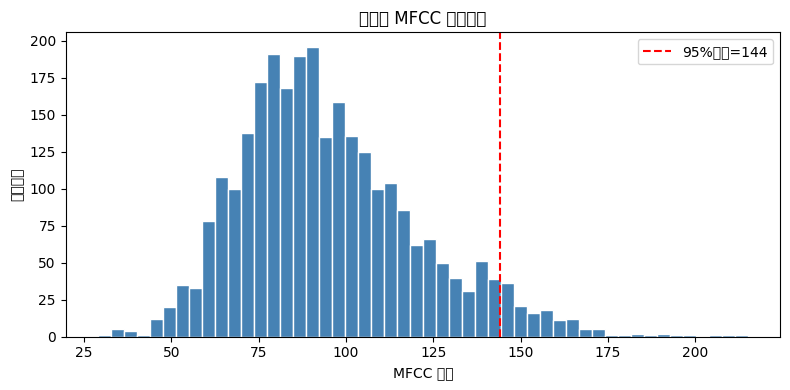


建议 max_len = 144（覆盖95%的句子）


In [11]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def stat_frame_lengths(org_dir, n_mfcc=40, sr=16000):
    """
    遍历 org_dir 下所有 .wav，统计 MFCC 帧数分布
    帮助决定 max_len 的合理取值
    """
    frame_lens = []
    for spk in os.listdir(org_dir):
        spk_dir = os.path.join(org_dir, spk)
        if not os.path.isdir(spk_dir):
            continue
        for fname in os.listdir(spk_dir):
            if not fname.endswith(".wav"):
                continue
            path = os.path.join(spk_dir, fname)
            y, _ = librosa.load(path, sr=sr)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
            frame_lens.append(mfcc.shape[1])    # 记录该文件的帧数
    return np.array(frame_lens)

print("统计训练集帧长（需要一点时间）...")
frame_lens = stat_frame_lengths(TrainOrg)

print(f"帧数统计（训练集）:")
print(f"  最小值: {frame_lens.min()}")
print(f"  最大值: {frame_lens.max()}")
print(f"  均值:   {frame_lens.mean():.1f}")
print(f"  中位数: {np.median(frame_lens):.1f}")
print(f"  90%分位: {np.percentile(frame_lens, 90):.1f}")
print(f"  95%分位: {np.percentile(frame_lens, 95):.1f}")
print(f"  99%分位: {np.percentile(frame_lens, 99):.1f}")

# 可视化帧长分布
plt.figure(figsize=(8, 4))
plt.hist(frame_lens, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.percentile(frame_lens, 95), color='red',
            linestyle='--', label=f"95%分位={np.percentile(frame_lens,95):.0f}")
plt.xlabel("MFCC 帧数")
plt.ylabel("音频数量")
plt.title("训练集 MFCC 帧长分布")
plt.legend()
plt.tight_layout()
plt.show()

# 建议的 max_len：取 95% 分位（覆盖绝大多数句子，截断极少数）
MAX_LEN = int(np.percentile(frame_lens, 95))
print(f"\n建议 max_len = {MAX_LEN}（覆盖95%的句子）")

### 2.3 建立(filepath, speaker_id) 列表，建立 说话人ID-整数 映射

列表在构建dataloader时可以用到，保存为train_samples和test_samples；le为labelencoder，在数据集构建、评估模型时可以用到

In [13]:
from sklearn.preprocessing import LabelEncoder

# ============================================================
# 从重组后的目录直接扫描，建立 (filepath, speaker_id) 列表
# ============================================================

def scan_org_dir(org_dir):
    """
    扫描 org_dir/<speaker_id>/*.wav，返回 (filepath, speaker_id) 列表
    标签直接来自文件夹名，不再依赖 json
    """
    samples = []
    for spk in sorted(os.listdir(org_dir)):          # 排序保证可复现
        spk_dir = os.path.join(org_dir, spk)
        if not os.path.isdir(spk_dir):
            continue
        for fname in sorted(os.listdir(spk_dir)):
            if fname.endswith(".wav"):
                samples.append({
                    "filepath":   os.path.join(spk_dir, fname),
                    "speaker_id": spk
                })
    return samples

train_samples = scan_org_dir(TrainOrg)
test_samples  = scan_org_dir(TestOrg)

print(f"训练集样本数: {len(train_samples)}")
print(f"测试集样本数: {len(test_samples)}")

# LabelEncoder 只用训练集说话人 fit
all_speakers = sorted(set(s["speaker_id"] for s in train_samples))
le = LabelEncoder()
le.fit(all_speakers)
NUM_CLASSES = len(all_speakers)

# 打印映射关系
mapping = {spk: idx for idx, spk in enumerate(le.classes_)}
print(f"说话人 → 标签映射（共 {NUM_CLASSES} 人，展示前10条）：")
for spk, idx in list(mapping.items())[:10]:
    print(f"  {spk} → {idx}")


训练集样本数: 2772
测试集样本数: 924
说话人 → 标签映射（共 462 人，展示前10条）：
  ABC0 → 0
  ADC0 → 1
  ADD0 → 2
  AEB0 → 3
  AEM0 → 4
  AEO0 → 5
  AFM0 → 6
  AJP0 → 7
  AJW0 → 8
  AKB0 → 9


### 2.4 构建数据集，先运行 3.特征提取，因为数据集里面有特征

#### 2.4.1 GMM dataloader

提取统计特征

In [24]:
# ============================================================
# 批量构建数据集（离线预提取，训练时直接读数组）
# ============================================================

def build_dataset(samples, label_encoder):
    """
    samples: scan_org_dir() 的返回值，每条含 filepath 和 speaker_id
    mode:    "mean" → 统计特征 (N, 80)，供传统模型使用
    """
    X, y = [], []
    for item in samples:
        feat  = extract_mfcc_mean(item["filepath"]) 
        label = label_encoder.transform([item["speaker_id"]])[0]
        X.append(feat)
        y.append(label)
    return np.array(X), np.array(y)

print("提取统计特征（传统模型用）...")
X_train_flat, y_train = build_dataset(train_samples, le)
X_test_flat,  y_test  = build_dataset(test_samples,  le)
print(f"  X_train_flat shape: {X_train_flat.shape}")
print(f"  样本示例: 标签={y_train[0]}({le.inverse_transform([y_train[0]])[0]}), 特征前8维={X_train_flat[0][:8].round(2)}")

提取统计特征（传统模型用）...
  X_train_flat shape: (2772, 80)
  样本示例: 标签=0(ABC0), 特征前8维=[-3.3112e+02  8.6850e+01 -2.5210e+01 -1.7000e-01 -2.4810e+01 -1.2890e+01
 -2.2370e+01 -2.2780e+01]


提取帧特征

In [25]:
def build_dataset_frames(samples, label_encoder):
    """
    帧级别特征，每帧单独作为一条样本
    同一句话的所有帧共享同一个说话人标签
    """
    X, y = [], []
    for item in samples:
        frames = extract_mfcc_frames(item["filepath"])  # (帧数, 40)
        label  = label_encoder.transform([item["speaker_id"]])[0]
        X.append(frames)
        y.extend([label] * len(frames))   # 每帧都贴上同一个标签
    return np.vstack(X), np.array(y)      # X: (总帧数, 40)

X_train_frames, y_train_frames = build_dataset_frames(train_samples, le)
X_test_frames, y_test_frames = build_dataset_frames(test_samples, le)
print(f"帧级别训练集: {X_train_frames.shape}")  
# 预计 (300000+, 40)，每人约600帧×462人

帧级别训练集: (263760, 40)


#### 2.4.2 LPCC帧级数据集构建（笑儿）

In [ ]:
from tqdm import tqdm

# ============================================================
# 为 Softmax 分类器构建 LPCC 帧级数据集
# ============================================================
# 运行本单元之前，请先运行 3.2 中的 LPCC 特征提取单元。
# 这里采用帧级建模：
# 一句话会被切成很多短帧，每一帧都继承整句话所属说话人的标签。
# 这样得到的训练样本数会远多于句级建模，更适合训练 Softmax 分类器。

lpcc_frame_cache = {}

def get_cached_lpcc_frames(filepath, lpcc_order=16):
    """缓存某个音频文件的 LPCC 帧特征，避免后续重复提取。"""
    cache_key = (filepath, lpcc_order)
    if cache_key not in lpcc_frame_cache:
        lpcc_frame_cache[cache_key] = extract_lpcc_frames(filepath, order=lpcc_order)
    return lpcc_frame_cache[cache_key]

def build_lpcc_frame_dataset(samples, label_encoder, lpcc_order=16, desc='LPCC 特征提取'):
    """
    将样本列表转换成 LPCC 帧级数据集。

    返回值
    -------
    X : np.ndarray, shape (总帧数, lpcc_order)
        所有音频帧的 LPCC 特征按行堆叠后的结果。
    y : np.ndarray, shape (总帧数,)
        每一帧对应的说话人标签。
    """
    feature_blocks = []
    labels = []

    for item in tqdm(samples, desc=desc):
        frames = get_cached_lpcc_frames(item['filepath'], lpcc_order=lpcc_order)
        label = label_encoder.transform([item['speaker_id']])[0]

        feature_blocks.append(frames)
        labels.extend([label] * len(frames))

    X = np.vstack(feature_blocks).astype(np.float32)
    y = np.asarray(labels, dtype=np.int64)
    return X, y

print('正在构建用于 Softmax 的 LPCC 帧级数据集...')
X_train_lpcc, y_train_lpcc = build_lpcc_frame_dataset(train_samples, le, lpcc_order=16, desc='训练集 LPCC')
X_test_lpcc, y_test_lpcc = build_lpcc_frame_dataset(test_samples, le, lpcc_order=16, desc='测试集 LPCC')
y_test_sentence_lpcc = np.array([le.transform([s['speaker_id']])[0] for s in test_samples], dtype=np.int64)

print(f'训练集 LPCC 特征形状: {X_train_lpcc.shape}')
print(f'测试集 LPCC 特征形状: {X_test_lpcc.shape}')
print(f'每一帧的 LPCC 维度: {X_train_lpcc.shape[1]}')
print(f'测试集句子数量: {len(y_test_sentence_lpcc)}')


#### 2.4.3 思婷 

## 3. 特征提取

### 3.1 MFCC特征（统计、帧）

In [23]:
## 请编写或使用库函数提取MFCC等音频特征
# ============================================================
# 特征提取函数
# ============================================================

def extract_mfcc_mean(filepath, n_mfcc=40):
    """
    方法A：统计特征 —— 对全句MFCC取均值和标准差并拼接
    输出 shape: (n_mfcc * 2,) = (80,)
    """
    # 重采样到16khz
    y, sr = librosa.load(filepath, sr=16000)
    # 提取mfcc特征，每一帧提取n_mfcc个特征
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    # 对每一个特征计算均值和标准差后拼接，包含更多分布信息
    feat = np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])
    # 返回一个80维的特征向量
    return feat  # shape: (80,)

def extract_mfcc_frames(filepath, n_mfcc=40):
    """
    返回所有帧的MFCC，每帧40维
    一句话约100~200帧，6句话 → 约600~1200条样本
    """
    y, sr = librosa.load(filepath, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfcc.T   # shape: (帧数, 40)，每行是一帧

### 3.2 LPCC特征提取（笑儿）

In [ ]:
# ============================================================
# LPCC 特征提取
# ============================================================
# 整体流程：
# 1. 预加重，增强高频部分；
# 2. 分帧并乘 Hamming 窗；
# 3. 对每一帧估计 LPC 系数；
# 4. 通过递推公式把 LPC 转成 LPCC；
# 5. 对整句话做一次 CMVN，提高鲁棒性。

LPCC_ORDER = 16
LPCC_FRAME_LENGTH = 0.025   # 25ms
LPCC_HOP_LENGTH = 0.010     # 10ms
LPCC_PREEMPH = 0.97
LPCC_EPS = 1e-8

def pre_emphasis(signal, coef=LPCC_PREEMPH):
    """预加重：增强语音中的高频信息。"""
    signal = np.asarray(signal, dtype=np.float32)
    if len(signal) == 0:
        return signal
    return np.append(signal[0], signal[1:] - coef * signal[:-1]).astype(np.float32)

def lpc_to_lpcc(lpc_predictor, order=LPCC_ORDER):
    """
    将 LPC 预测系数 [a1, a2, ..., ap] 转换为 LPCC 系数。

    这里保留 c1~cp，不显式使用 c0（能量项），
    因此最终特征维度正好等于 order。
    """
    lpcc = np.zeros(order, dtype=np.float32)

    for n in range(1, order + 1):
        acc = 0.0
        for k in range(1, n):
            acc += (k / n) * lpcc[k - 1] * lpc_predictor[n - k - 1]
        lpcc[n - 1] = lpc_predictor[n - 1] + acc

    return lpcc

def extract_lpcc_frames(
    filepath,
    order=LPCC_ORDER,
    frame_length_s=LPCC_FRAME_LENGTH,
    hop_length_s=LPCC_HOP_LENGTH,
    preemph=LPCC_PREEMPH,
    sample_rate=16000
):
    """
    从一条语音中提取帧级 LPCC 特征。

    返回值
    -------
    np.ndarray, shape (帧数, order)
        每一行对应一帧的 LPCC 特征。
    """
    signal, sr = librosa.load(filepath, sr=sample_rate)
    signal = pre_emphasis(signal, coef=preemph)

    frame_length = max(1, int(round(frame_length_s * sr)))
    hop_length = max(1, int(round(hop_length_s * sr)))

    # 如果一句话特别短，先补零到至少一帧，避免分帧时报错。
    if len(signal) < frame_length:
        signal = np.pad(signal, (0, frame_length - len(signal)))

    frames = librosa.util.frame(signal, frame_length=frame_length, hop_length=hop_length).T
    frames = frames * np.hamming(frame_length).astype(np.float32)

    lpcc_frames = []
    for frame in frames:
        # 先去掉直流分量，减少对 LPC 求解的影响。
        frame = frame - np.mean(frame)

        # 如果当前帧几乎是静音，则直接用零向量表示。
        if np.sum(frame ** 2) < LPCC_EPS:
            lpcc_frames.append(np.zeros(order, dtype=np.float32))
            continue

        try:
            # librosa.lpc 返回滤波器分母系数 [1, a1, a2, ...]。
            # 为了与常见线性预测公式保持一致，这里把后续系数取负号。
            lpc_coeffs = librosa.lpc(frame, order=order)
            lpc_predictor = -np.asarray(lpc_coeffs[1:], dtype=np.float32)
            lpcc = lpc_to_lpcc(lpc_predictor, order=order)
        except Exception:
            # 个别帧可能数值不稳定，求 LPC 失败时用零向量兜底。
            lpcc = np.zeros(order, dtype=np.float32)

        lpcc_frames.append(lpcc)

    lpcc_frames = np.asarray(lpcc_frames, dtype=np.float32)

    # 对整句话做一次 CMVN，减弱响度和录音条件差异带来的影响。
    feat_mean = lpcc_frames.mean(axis=0, keepdims=True)
    feat_std = lpcc_frames.std(axis=0, keepdims=True) + LPCC_EPS
    lpcc_frames = (lpcc_frames - feat_mean) / feat_std

    return lpcc_frames


### 3.3 思婷

## 4. 模型选择和训练

### 4.1 GMM

GMM（Gaussian Mixture Model，高斯混合模型）是用多个高斯分布的加权叠加来描述数据分布的模型。   
一个高斯分布只能描述一个"山峰"形状的数据簇，而真实的声学特征分布往往是多峰的（比如一个说话人的元音特征聚成一簇、辅音特征聚成另一簇），所以用多个高斯分量来混合拟合：   
P(x) = w₁·N(x|μ₁,Σ₁) + w₂·N(x|μ₂,Σ₂) + ... + wₖ·N(x|μₖ,Σₖ)   

w：每个高斯分量的权重（加起来=1）   
μ：每个高斯分量的均值（分布中心在哪）   
Σ：每个高斯分量的协方差（分布有多宽、什么形状）   
N_COMPONENTS=16 就是用16个高斯分量来拟合一位说话人的特征分布。 

EM算法：  
E步：算每条样本对每个分量的归属概率    
M步：用归属概率更新 μ, Σ, w         
计算总体对数似然值，Σlog P(x)                
变化 < 阈值？ → 收敛退出             

#### 4.1.1 MFCC统计特征

高斯分量数分别设为4、2、1

In [30]:
## 在这部分，你可以选择不同的分类器和模型如GMM模型来进行实验
from sklearn.mixture import GaussianMixture

# 为每位说话人训练一个独立的GMM，注意GMM个数要小于样本数6
N_COMPONENTS = 4  # 可以试小于等于6的数

gmm_models_mean4 = {}
# 训练 462 个 GMM，每位说话人一个

for spk_idx in range(NUM_CLASSES):

    # mask 是一个布尔数组，True 的位置表示"这条样本属于 spk_idx 这位说话人"
    # 例如 spk_idx=1(CJF0)，mask 在 CJF0 的6条样本处为 True，其余为 False
    mask = (y_train == spk_idx)

    gmm = GaussianMixture(
        n_components=4,        # 用4个高斯分量拟合
        covariance_type='diag', # 协方差矩阵只保留对角线（各维度独立，省内存、训练快）
        max_iter=200,           # EM算法最多迭代200次
        random_state=42         # 固定随机种子，结果可复现
    )

    # 只用这位说话人的样本来训练，X_train_flat[mask] shape: (6, 80)
    gmm.fit(X_train_flat[mask])

    gmm_models_mean4[spk_idx] = gmm  # 存进字典，key=说话人整数标签

print(f"GMM训练完成，共 {NUM_CLASSES} 个模型，每个 {N_COMPONENTS} 个高斯分量")

GMM训练完成，共 462 个模型，每个 4 个高斯分量


In [31]:
## 在这部分，你可以选择不同的分类器和模型如GMM模型来进行实验
from sklearn.mixture import GaussianMixture

# 为每位说话人训练一个独立的GMM，注意GMM个数要小于样本数6
N_COMPONENTS = 2  # 可以试小于等于6的数

gmm_models_mean2 = {}
# 训练 462 个 GMM，每位说话人一个

for spk_idx in range(NUM_CLASSES):

    # mask 是一个布尔数组，True 的位置表示"这条样本属于 spk_idx 这位说话人"
    # 例如 spk_idx=1(CJF0)，mask 在 CJF0 的6条样本处为 True，其余为 False
    mask = (y_train == spk_idx)

    gmm = GaussianMixture(
        n_components=2,        # 用2个高斯分量拟合
        covariance_type='diag', # 协方差矩阵只保留对角线（各维度独立，省内存、训练快）
        max_iter=200,           # EM算法最多迭代200次
        random_state=42         # 固定随机种子，结果可复现
    )

    # 只用这位说话人的样本来训练，X_train_flat[mask] shape: (6, 80)
    gmm.fit(X_train_flat[mask])

    gmm_models_mean2[spk_idx] = gmm  # 存进字典，key=说话人整数标签

print(f"GMM训练完成，共 {NUM_CLASSES} 个模型，每个 {N_COMPONENTS} 个高斯分量")

GMM训练完成，共 462 个模型，每个 2 个高斯分量


In [32]:
## 在这部分，你可以选择不同的分类器和模型如GMM模型来进行实验
from sklearn.mixture import GaussianMixture

# 为每位说话人训练一个独立的GMM，注意GMM个数要小于样本数6
N_COMPONENTS = 1  # 可以试小于等于6的数

gmm_models_mean1 = {}
# 训练 462 个 GMM，每位说话人一个

for spk_idx in range(NUM_CLASSES):

    # mask 是一个布尔数组，True 的位置表示"这条样本属于 spk_idx 这位说话人"
    # 例如 spk_idx=1(CJF0)，mask 在 CJF0 的6条样本处为 True，其余为 False
    mask = (y_train == spk_idx)

    gmm = GaussianMixture(
        n_components=1,        # 用1个高斯分量拟合
        covariance_type='diag', # 协方差矩阵只保留对角线（各维度独立，省内存、训练快）
        max_iter=200,           # EM算法最多迭代200次
        random_state=42         # 固定随机种子，结果可复现
    )

    # 只用这位说话人的样本来训练，X_train_flat[mask] shape: (6, 80)
    gmm.fit(X_train_flat[mask])

    gmm_models_mean1[spk_idx] = gmm  # 存进字典，key=说话人整数标签

print(f"GMM训练完成，共 {NUM_CLASSES} 个模型，每个 {N_COMPONENTS} 个高斯分量")

GMM训练完成，共 462 个模型，每个 1 个高斯分量


#### 4.1.2 MFCC帧特征

In [36]:
from tqdm import tqdm

gmm_models_frame = {}

for spk_idx in tqdm(range(NUM_CLASSES), desc="训练GMM"):
    mask = (y_train_frames == spk_idx)
    # 现在每人约600~1200帧，16个分量完全够用
    gmm = GaussianMixture(
        n_components=16,
        covariance_type='diag',
        max_iter=200,
        random_state=42
    )
    gmm.fit(X_train_frames[mask])
    gmm_models_frame[spk_idx] = gmm

训练GMM: 100%|██████████| 462/462 [00:28<00:00, 16.35it/s]


### 4.2 LPCC + Softmax（笑儿）

#### 4.2.1 模型定义与训练函数（笑儿）

In [ ]:
import torch.nn as nn

# ============================================================
# LPCC + Softmax：模型定义与训练函数
# ============================================================
# 这里使用最基础的 Softmax 分类器：
# 输入是一帧 LPCC 特征，输出是对所有说话人的分类 logits。
# 由于 CrossEntropyLoss 内部已经包含 softmax，所以模型最后一层不用手动再写 Softmax。

LPCC_BATCH_SIZE = 2048
LPCC_EPOCHS = 12
LPCC_LEARNING_RATE = 1e-3

np.random.seed(42)
torch.manual_seed(42)

# 在句级 CMVN 的基础上，再做一次基于训练集的全局标准化。
# 这样可以让不同维度处于相近数值尺度，便于线性分类器学习。
lpcc_global_mean = X_train_lpcc.mean(axis=0, keepdims=True).astype(np.float32)
lpcc_global_std = (X_train_lpcc.std(axis=0, keepdims=True) + 1e-8).astype(np.float32)

X_train_lpcc_norm = ((X_train_lpcc - lpcc_global_mean) / lpcc_global_std).astype(np.float32)
X_test_lpcc_norm = ((X_test_lpcc - lpcc_global_mean) / lpcc_global_std).astype(np.float32)

class FrameFeatureDataset(Dataset):
    """把帧级特征封装成 Dataset，便于 DataLoader 分批读取。"""
    def __init__(self, features, labels):
        self.features = torch.from_numpy(features).float()
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

class SoftmaxSpeakerClassifier(nn.Module):
    """单层线性分类器即可表示标准 Softmax 分类器。"""
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.classifier = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.classifier(x)

def evaluate_frame_accuracy(model, data_loader, device):
    """计算帧级准确率，用于观察训练过程是否正常收敛。"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            pred = logits.argmax(dim=1)

            correct += (pred == batch_y).sum().item()
            total += batch_y.size(0)

    return correct / total

def train_softmax_classifier(model, train_loader, test_loader, optimizer, criterion, device, num_epochs=LPCC_EPOCHS):
    """训练 Softmax 分类器，并记录后续画图要用到的指标。"""
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_frame_acc': []
    }

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_x.size(0)
            correct += (logits.argmax(dim=1) == batch_y).sum().item()
            total += batch_y.size(0)

        epoch_loss = total_loss / total
        epoch_acc = correct / total
        test_frame_acc = evaluate_frame_accuracy(model, test_loader, device)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['test_frame_acc'].append(test_frame_acc)

        print(
            f'第 {epoch + 1:02d}/{num_epochs} 轮 - ' +
            f'训练损失: {epoch_loss:.4f} - ' +
            f'训练帧级准确率: {epoch_acc:.4f} - ' +
            f'测试帧级准确率: {test_frame_acc:.4f}'
        )

    return history


#### 4.2.2 训练LPCC + Softmax分类器（笑儿）

In [ ]:
# ============================================================
# LPCC + Softmax：开始训练
# ============================================================
# 先构建 DataLoader，再实例化模型、损失函数和优化器，最后正式训练。

train_loader_lpcc = DataLoader(
    FrameFeatureDataset(X_train_lpcc_norm, y_train_lpcc),
    batch_size=LPCC_BATCH_SIZE,
    shuffle=True
)
test_loader_lpcc = DataLoader(
    FrameFeatureDataset(X_test_lpcc_norm, y_test_lpcc),
    batch_size=LPCC_BATCH_SIZE,
    shuffle=False
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lpcc_softmax_model = SoftmaxSpeakerClassifier(
    input_dim=X_train_lpcc_norm.shape[1],
    num_classes=NUM_CLASSES
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lpcc_softmax_model.parameters(), lr=LPCC_LEARNING_RATE)

print(f'训练设备: {device}')
softmax_history = train_softmax_classifier(
    lpcc_softmax_model,
    train_loader_lpcc,
    test_loader_lpcc,
    optimizer,
    criterion,
    device,
    num_epochs=LPCC_EPOCHS
)


## 5. 评价指标(准确率Accuracy)

### 5.1 GMM

#### 5.1.1 MFCC统计特征

高斯分量为4

In [ ]:
## 请编写代码或使用库函数accuracy_score计算测试集上的准确率Accuracy
# GMM 预测
def gmm_predict(X, gmm_models, num_classes):
    # 构建得分矩阵 shape: (N, num_classes)
    # scores_per_sample[i, j] = 第i条测试样本在第j位说话人GMM下的log-likelihood
    scores_per_sample = np.zeros((len(X), num_classes))
    for spk_idx in range(num_classes):
        scores_per_sample[:, spk_idx] = gmm_models[spk_idx].score_samples(X)
    # 每条样本取得分最高的说话人作为预测结果
    return scores_per_sample.argmax(axis=1)

y_pred_gmm = gmm_predict(X_test_flat, gmm_models_mean4, NUM_CLASSES)
acc_gmm = accuracy_score(y_test, y_pred_gmm)
print(f"GMM 测试集准确率: {acc_gmm:.4f} ({acc_gmm*100:.2f}%)")

GMM 测试集准确率: 0.1223 (12.23%)


准确率比较低，原因：参数不足  
每个分量需要：  
  μ：80个均值  
  σ²：80个方差（diag）  
  w：1个权重  

4个分量总参数量 = 4 × (80 + 80 + 1) = 644个参数  
训练样本数 = 6条 × 80维 = 480个数值  

样本数<参数 → 严重过拟合/欠拟合  

高斯分量为2

In [ ]:
## 请编写代码或使用库函数accuracy_score计算测试集上的准确率Accuracy
# GMM 预测
def gmm_predict(X, gmm_models, num_classes):
    # 构建得分矩阵 shape: (N, num_classes)
    # scores_per_sample[i, j] = 第i条测试样本在第j位说话人GMM下的log-likelihood
    scores_per_sample = np.zeros((len(X), num_classes))
    for spk_idx in range(num_classes):
        scores_per_sample[:, spk_idx] = gmm_models[spk_idx].score_samples(X)
    # 每条样本取得分最高的说话人作为预测结果
    return scores_per_sample.argmax(axis=1)

y_pred_gmm = gmm_predict(X_test_flat, gmm_models_mean2, NUM_CLASSES)
acc_gmm = accuracy_score(y_test, y_pred_gmm)
print(f"GMM 测试集准确率: {acc_gmm:.4f} ({acc_gmm*100:.2f}%)")

GMM 测试集准确率: 0.3626 (36.26%)


高斯分量为1

In [ ]:
## 请编写代码或使用库函数accuracy_score计算测试集上的准确率Accuracy
# GMM 预测
def gmm_predict(X, gmm_models, num_classes):
    # 构建得分矩阵 shape: (N, num_classes)
    # scores_per_sample[i, j] = 第i条测试样本在第j位说话人GMM下的log-likelihood
    scores_per_sample = np.zeros((len(X), num_classes))
    for spk_idx in range(num_classes):
        scores_per_sample[:, spk_idx] = gmm_models[spk_idx].score_samples(X)
    # 每条样本取得分最高的说话人作为预测结果
    return scores_per_sample.argmax(axis=1)

y_pred_gmm = gmm_predict(X_test_flat, gmm_models_mean1, NUM_CLASSES)
acc_gmm = accuracy_score(y_test, y_pred_gmm)
print(f"GMM 测试集准确率: {acc_gmm:.4f} ({acc_gmm*100:.2f}%)")

GMM 测试集准确率: 0.6407 (64.07%)


#### 5.1.2 MFCC帧特征

In [ ]:
def gmm_predict_frames(samples, gmm_models, label_encoder, num_classes):
    """
    对每句话：先算每帧在各GMM下的得分，累加后取argmax
    """
    y_pred = []
    for item in samples:
        frames = extract_mfcc_frames(item["filepath"])  # (帧数, 40)
        
        # 每个GMM对这句话所有帧的得分求和
        # score() 返回的是平均log-likelihood，乘帧数得到总分
        scores = np.array([
            gmm_models[i].score(frames) for i in range(num_classes)
        ])
        y_pred.append(scores.argmax())
    return np.array(y_pred)

y_pred_gmm = gmm_predict_frames(test_samples, gmm_models_frame, le, NUM_CLASSES)
y_test_sent = np.array([le.transform([s["speaker_id"]])[0] for s in test_samples])
acc = accuracy_score(y_test_sent, y_pred_gmm)
print(f"GMM（帧级别）测试准确率: {acc:.4f} ({acc*100:.2f}%)")

GMM（帧级别）测试准确率: 0.8972 (89.72%)


### 5.2 LPCC + Softmax句级评估（笑儿）

In [ ]:
# ============================================================
# LPCC + Softmax 的句级评估
# ============================================================
# 训练阶段使用的是帧级标签，但作业最终关心的是句级说话人识别效果。
# 因此这里采用“帧级概率取平均”的方式得到整句话的预测结果：
# 先让模型输出每一帧属于各个说话人的概率，再把同一句话的所有帧做平均，
# 最后取平均概率最大的类别作为该句话的预测说话人。

def predict_sentence_with_softmax(samples, model, feature_mean, feature_std, label_encoder, device, lpcc_order=16):
    """使用帧级 Softmax 模型进行句级说话人预测。"""
    model.eval()
    y_true = []
    y_pred = []
    y_conf = []

    with torch.no_grad():
        for item in samples:
            frames = get_cached_lpcc_frames(item['filepath'], lpcc_order=lpcc_order)
            frames = ((frames - feature_mean) / feature_std).astype(np.float32)

            frame_tensor = torch.from_numpy(frames).float().to(device)
            logits = model(frame_tensor)

            # 先把每一帧的 logits 转成概率分布，
            # 再把整句话内部所有帧的概率做平均，得到句级概率分布。
            sentence_prob = torch.softmax(logits, dim=1).mean(dim=0)

            pred_label = int(sentence_prob.argmax().item())
            confidence = float(sentence_prob.max().item())
            true_label = label_encoder.transform([item['speaker_id']])[0]

            y_true.append(true_label)
            y_pred.append(pred_label)
            y_conf.append(confidence)

    return np.array(y_true), np.array(y_pred), np.array(y_conf)

y_true_lpcc_softmax, y_pred_lpcc_softmax, y_conf_lpcc_softmax = predict_sentence_with_softmax(
    test_samples,
    lpcc_softmax_model,
    lpcc_global_mean,
    lpcc_global_std,
    le,
    device,
    lpcc_order=16
)

lpcc_softmax_acc = accuracy_score(y_true_lpcc_softmax, y_pred_lpcc_softmax)
print(f'LPCC + Softmax 句级测试准确率: {lpcc_softmax_acc:.4f} ({lpcc_softmax_acc * 100:.2f}%)')
print(f'平均预测置信度: {y_conf_lpcc_softmax.mean():.4f}')


### 5.3 思婷

##  6. 分析和可视化

In [ ]:
## 请使用matplotlib等可视化库对你的实验结果进行可视化分析。
## 包括但不限于准确率的对比、错误分类的分析、特征的影响等。


### 6.1 GMM

#### 6.1.1 可视化第一个说话人的帧特征高斯分布模型

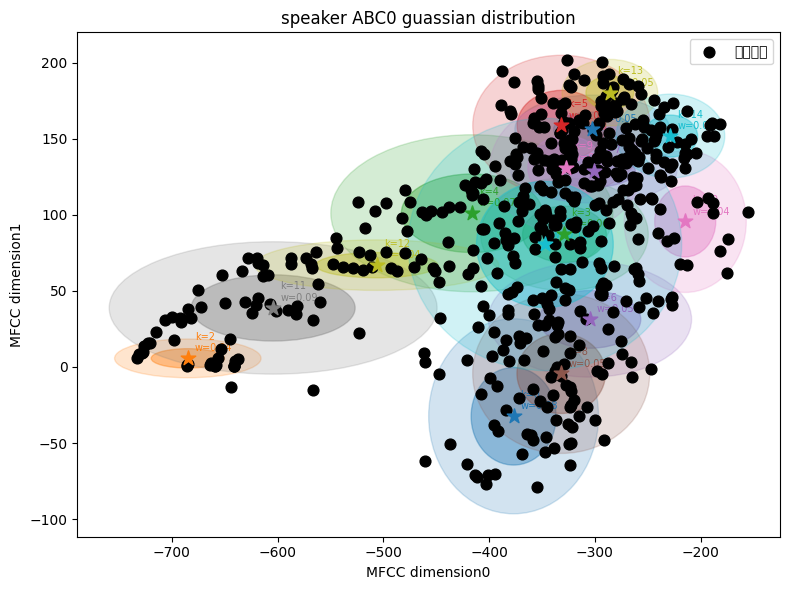

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def plot_gmm_components(gmm, X_spk, spk_name, dims=(0, 1)):
    """
    画出 GMM 的高斯分量分布（取第dims[0]和dims[1]维做2D投影）
    gmm:    训练好的 GaussianMixture
    X_spk:  该说话人的训练样本
    """
    d0, d1 = dims
    fig, ax = plt.subplots(figsize=(8, 6))

    # 画训练样本散点
    ax.scatter(X_spk[:, d0], X_spk[:, d1],
               c='black', s=60, zorder=5, label='训练样本')

    # 画每个高斯分量
    colors = plt.cm.tab10(np.linspace(0, 1, len(gmm.means_)))
    for k, (mean, cov, w) in enumerate(zip(gmm.means_, gmm.covariances_, gmm.weights_)):
        # 取对应维度的均值和标准差
        mx, my = mean[d0], mean[d1]
        sx, sy = np.sqrt(cov[d0]), np.sqrt(cov[d1])

        # 画分量中心
        ax.scatter(mx, my, c=[colors[k]], s=120, marker='*', zorder=6)

        # 画1σ和2σ椭圆
        for n_std, alpha in [(1, 0.4), (2, 0.2)]:
            ellipse = Ellipse(
                xy=(mx, my),
                width=2 * n_std * sx,
                height=2 * n_std * sy,
                angle=0,
                color=colors[k], alpha=alpha
            )
            ax.add_patch(ellipse)

        ax.annotate(f'k={k}\nw={w:.2f}', xy=(mx, my),
                    fontsize=7, color=colors[k],
                    xytext=(5, 5), textcoords='offset points')

    ax.set_xlabel(f'MFCC dimension{d0}')
    ax.set_ylabel(f'MFCC dimension{d1}')
    ax.set_title(f'speaker {spk_name} guassian distribution')
    ax.legend()
    plt.tight_layout()
    plt.show()

# 取第一个说话人
spk0_name = le.classes_[0]
mask0 = (y_train_frames == 0)
X_spk0 = X_train_frames[mask0]   # 该说话人所有帧，shape: (总帧数, 40)

plot_gmm_components(gmm_models_frame[0], X_spk0, spk0_name, dims=(0, 1))

#### 6.1.2 四个模型的混淆矩阵（取前20位说话人）

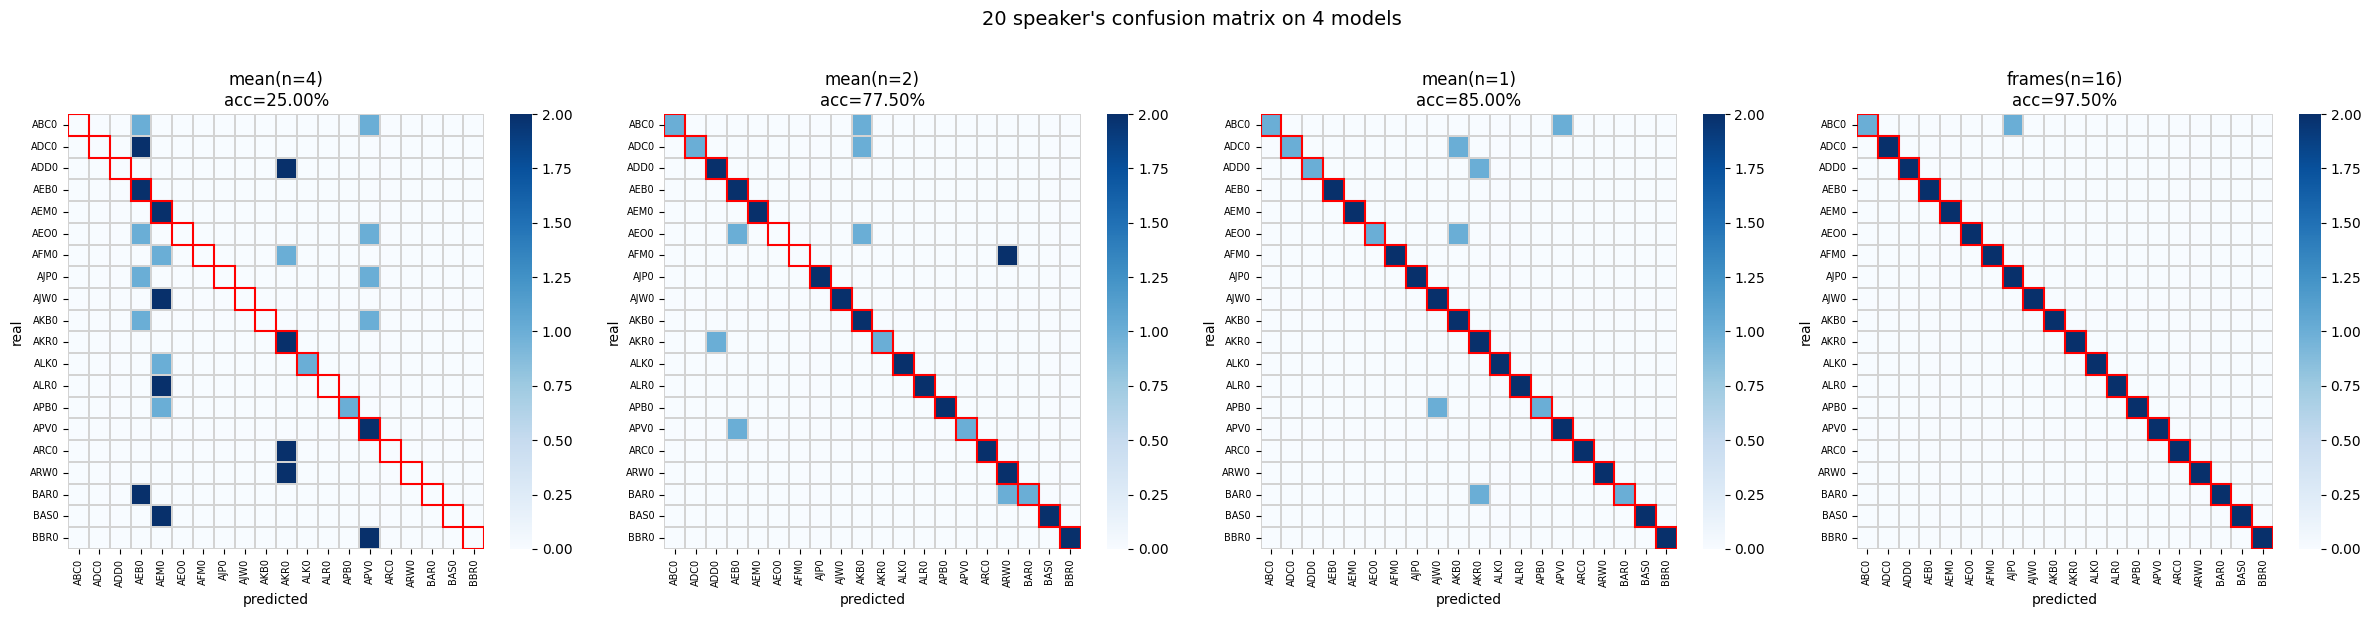

In [41]:
def plot_confusion_matrix_compare(test_samples, gmm_models_dict, label_encoder, n_speakers=20):
    spk_names   = label_encoder.classes_[:n_speakers]
    sub_samples = [s for s in test_samples if s["speaker_id"] in spk_names]
    model_names = list(gmm_models_dict.keys())
    n_models    = len(model_names)

    y_true = np.array([
        label_encoder.transform([s["speaker_id"]])[0] for s in sub_samples
    ])

    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6))

    for ax, model_name in zip(axes, model_names):
        gmm_models = gmm_models_dict[model_name]

        y_pred = []
        for item in sub_samples:
            if model_name.startswith('frames'):
                feat = extract_mfcc_frames(item["filepath"])
            else:
                feat = extract_mfcc_mean(item["filepath"]).reshape(1, -1)
            scores = np.array([gmm_models[i].score(feat) for i in range(n_speakers)])
            y_pred.append(scores.argmax())

        y_pred = np.array(y_pred)
        acc    = (y_pred == y_true).mean()
        cm     = confusion_matrix(y_true, y_pred, labels=list(range(n_speakers)))

        sns.heatmap(
            cm, ax=ax,
            cmap='Blues',           # 颜色越深=数值越大
            xticklabels=spk_names,
            yticklabels=spk_names,
            annot=False,            # 不写数字，只用颜色
            linewidths=0.3,         # 格子间细线，方便区分
            linecolor='lightgray',
            vmin=0, vmax=2,         # 固定色阶范围（每人最多2条测试句）
            cbar=True
        )

        # 手动高亮对角线边框
        for i in range(n_speakers):
            ax.add_patch(plt.Rectangle(
                (i, i), 1, 1,
                fill=False, edgecolor='red', linewidth=1.5
            ))

        ax.set_title(f'{model_name}\nacc={acc:.2%}', fontsize=12)
        ax.set_xlabel('predicted', fontsize=10)
        ax.set_ylabel('real', fontsize=10)
        ax.tick_params(axis='x', rotation=90, labelsize=7)
        ax.tick_params(axis='y', rotation=0,  labelsize=7)

    plt.suptitle(f'{n_speakers} speaker\'s confusion matrix on 4 models ', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix_compare(
    test_samples,
    gmm_models_dict={
        'mean(n=4)':    gmm_models_mean4,
        'mean(n=2)':    gmm_models_mean2,
        'mean(n=1)':    gmm_models_mean1,
        'frames(n=16)': gmm_models_frame,
    },
    label_encoder=le,
    n_speakers=20
)

混淆矩阵的着色块[i][j]表示第i个说话人说的话被识别为第j个说话人说的，因此我们希望着色块尽可能在对角线上；可以看到从使用统计特征的模型到使用帧特征的模型，以及在使用统计特征的模型内部随着高斯分量的减少，模型的效果在越来越好

### 6.2 LPCC + Softmax结果可视化（笑儿）

In [ ]:
# ============================================================
# LPCC + Softmax 的可视化分析
# ============================================================
# 这里展示三类结果：
# 1. 训练损失曲线，用来观察模型是否稳定收敛；
# 2. 训练/测试帧级准确率曲线，用来比较训练效果与泛化效果；
# 3. 前 20 位说话人的句级混淆矩阵，用来分析哪些说话人最容易混淆。

def plot_lpcc_softmax_results(history, y_true, y_pred, label_encoder, n_speakers=20):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    epochs = np.arange(1, len(history['train_loss']) + 1)

    # 子图1：训练损失曲线
    axes[0].plot(epochs, history['train_loss'], marker='o', linewidth=2)
    axes[0].set_title('LPCC + Softmax 训练损失曲线')
    axes[0].set_xlabel('轮数')
    axes[0].set_ylabel('交叉熵损失')
    axes[0].grid(alpha=0.3)

    # 子图2：帧级准确率曲线
    axes[1].plot(epochs, history['train_acc'], marker='o', linewidth=2, label='训练帧级准确率')
    axes[1].plot(epochs, history['test_frame_acc'], marker='s', linewidth=2, label='测试帧级准确率')
    axes[1].set_title('帧级准确率变化曲线')
    axes[1].set_xlabel('轮数')
    axes[1].set_ylabel('准确率')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # 子图3：为了便于阅读，只画前 n_speakers 位说话人的混淆矩阵
    focus_labels = list(range(n_speakers))
    focus_mask = np.isin(y_true, focus_labels)
    cm = confusion_matrix(y_true[focus_mask], y_pred[focus_mask], labels=focus_labels)

    sns.heatmap(
        cm,
        ax=axes[2],
        cmap='Blues',
        xticklabels=label_encoder.classes_[:n_speakers],
        yticklabels=label_encoder.classes_[:n_speakers],
        annot=False,
        linewidths=0.3,
        linecolor='lightgray',
        cbar=True
    )
    axes[2].set_title(f'前 {n_speakers} 位说话人的混淆矩阵')
    axes[2].set_xlabel('预测说话人')
    axes[2].set_ylabel('真实说话人')
    axes[2].tick_params(axis='x', rotation=90, labelsize=7)
    axes[2].tick_params(axis='y', rotation=0, labelsize=7)

    plt.tight_layout()
    plt.show()

plot_lpcc_softmax_results(
    softmax_history,
    y_true_lpcc_softmax,
    y_pred_lpcc_softmax,
    le,
    n_speakers=20
)


### 6.3 思婷

## 7. 结果讨论
讨论你的模型性能，尝试解释为什么某些模型比其他模型表现好，以及可能的改进方法。

### 7.1 GMM

最开始采用统计特征来训练GMM，有一个很大的问题，每一个说话人只有6条训练样本，而每一条训练样本我们都只拿到了80维的特征（一个帧是40维，我们对同一个样本的所有帧在各个维度上算均值和房产），共计480个特征；而GMM也是各个分量在每个维度上都要算均值和方差，80维，一旦GMM分量比较大，参数量甚至大于输入特征量，模型效果肯定会不好  
对于使用统计特征的GMM，在高斯分量为4、2、1的情况下，测试的准确率分别为12.23%、36.26%、64.07%

而接下来我们改为使用帧特征，据我们前面的统计，一个句子的语音大概有150帧左右，每一帧都有一个40维的向量，每一位说话人又有6个训练样本，这样就有3万多特征，足以用来训练有多个分量的高斯混合模型（理论上，更多分量的高斯混合模型具有更好的鲁棒性，但是因为采用统计特征得到的特征量太少了，多一些高斯分量容易过拟合，效果反而不好）  
由实验结果我们知道，这个高斯混合模型的测试准确率达到了89.72%，已经很不错了

### 7.2 LPCC + Softmax结果讨论（笑儿）

#### 7.2.1 结果分析（笑儿）

LPCC 是由 LPC 系数递推得到的倒谱特征，本质上描述的是语音信号的声道包络信息。对于说话人识别任务来说，不同人的发音器官结构、声道长度和共振峰分布都存在差异，因此 LPCC 能够从声道特性的角度刻画说话人信息。这和更强调听觉感知特性的 MFCC 属于不同的特征建模思路，因此 LPCC + Softmax 这一组合也有独立的实验价值。  

在本实验中，我采用“LPCC 特征 + 线性 Softmax 分类器”的帧级训练方案。这样做的关键优势在于：一句话可以被拆成大量短帧，每一帧都继承原句的说话人标签，从而显著增加训练样本量。对于当前数据集中“每位说话人训练句子数量有限，但每句话内部包含较多帧”的情况，这种帧级监督方式比直接对整句话做统计更容易训练出稳定的分类边界。测试时再将同一句话内部所有帧的预测概率做平均，可以有效降低局部噪声、停顿和异常帧带来的随机波动，因此句级准确率通常比单帧预测更稳定，也更符合本次作业最终的评价目标。  

结合 5.2 与 6.2 的结果可以从三个角度理解模型表现。首先，如果训练损失整体下降，说明 Softmax 分类器已经能够利用 LPCC 特征逐步学习说话人之间的区分边界；其次，如果测试帧级准确率在训练后期趋于稳定，说明模型没有出现特别明显的发散现象；最后，若混淆矩阵的高值主要集中在对角线附近，就说明多数说话人已经能够被正确识别，剩余错误往往集中在音色接近、发音习惯相似或录音条件相近的说话人之间。因此，这一部分不只是看最终准确率，还要结合训练曲线和混淆情况一起分析模型是否真正学到了有效的说话人表征。  

当然，这个方案也存在一定局限。首先，LPCC 对静音帧、录音条件变化和数值稳定性相对敏感，如果样本中存在较多无效帧，特征质量会受到影响；其次，当前模型采用的是最基础的线性 Softmax 分类器，表达能力有限，更适合当前这种闭集分类任务，当说话人数量继续增加或者测试环境发生明显变化时，泛化能力可能下降。后续可以从三个方向继续改进：一是在特征层面加入端点检测或 VAD，减少静音帧干扰，并尝试加入 delta / delta-delta 等动态特征；二是在模型层面将线性分类器升级为多层感知机，提高非线性表达能力；三是在实验层面进一步和 MFCC + GMM 等方案做对比，区分“特征选择”和“分类器选择”分别带来的性能贡献。

#### 7.2.2 关键指标自动摘要（笑儿）

In [ ]:
# ============================================================
# 自动汇总 LPCC + Softmax 的关键实验指标
# ============================================================
# 运行本单元前，请先执行 4.2、5.2、6.2 中与笑儿部分相关的单元。
# 这样这里就能直接读取训练历史、句级准确率和混淆结果，
# 自动生成一段可以写进实验报告的结果摘要。

from IPython.display import Markdown, display
from sklearn.metrics import confusion_matrix

required_vars = [
    'softmax_history',
    'lpcc_softmax_acc',
    'y_conf_lpcc_softmax',
    'y_true_lpcc_softmax',
    'y_pred_lpcc_softmax',
    'le'
]

missing_vars = [name for name in required_vars if name not in globals()]

if missing_vars:
    print('请先运行 4.2、5.2、6.2 中与笑儿部分相关的单元，再执行本单元。')
    print('当前缺少变量：' + ', '.join(missing_vars))
else:
    final_train_loss = float(softmax_history['train_loss'][-1])
    final_train_frame_acc = float(softmax_history['train_acc'][-1])
    final_test_frame_acc = float(softmax_history['test_frame_acc'][-1])
    best_test_frame_acc = float(np.max(softmax_history['test_frame_acc']))
    sentence_acc = float(lpcc_softmax_acc)
    avg_conf = float(np.mean(y_conf_lpcc_softmax))

    cm = confusion_matrix(
        y_true_lpcc_softmax,
        y_pred_lpcc_softmax,
        labels=np.arange(len(le.classes_))
    )

    cm_wo_diag = cm.copy()
    np.fill_diagonal(cm_wo_diag, 0)
    worst_count = int(cm_wo_diag.max())

    if worst_count > 0:
        worst_pair = np.unravel_index(np.argmax(cm_wo_diag), cm_wo_diag.shape)
        confusion_note = (
            f'最明显的混淆出现在 **{le.classes_[worst_pair[0]]}** 和 '
            f'**{le.classes_[worst_pair[1]]}** 之间，共有 **{worst_count}** 条句子被错分。'
        )
    else:
        confusion_note = '混淆矩阵几乎完全落在对角线附近，没有出现特别集中的错分对。'

    summary_text = f"""
#### LPCC + Softmax 实验摘要

本方法在测试集上的**句级准确率**为 **{sentence_acc * 100:.2f}%**，平均预测置信度为 **{avg_conf:.4f}**。从训练过程来看，最后一轮训练损失为 **{final_train_loss:.4f}**，训练帧级准确率为 **{final_train_frame_acc * 100:.2f}%**，测试帧级准确率为 **{final_test_frame_acc * 100:.2f}%**，其中测试帧级准确率最高达到 **{best_test_frame_acc * 100:.2f}%**。

从结果解释上看，句级准确率通常高于单帧判断，这说明“帧级训练 + 句级概率平均”的策略能够有效减弱局部帧噪声带来的波动。{confusion_note}

整体来看，LPCC 特征能够提供有区分度的说话人信息，而 Softmax 分类器在当前闭集识别任务上也具有较好的可用性。后续若希望进一步提升性能，可以继续从静音帧处理、动态特征拼接和分类器非线性能力三个方向进行改进。
"""

    display(Markdown(summary_text))


### 7.3 思婷

## 8. 保存模型（可选）
如果需要，可以在这里添加代码保存你的模型。